<a href="https://colab.research.google.com/github/nepslor/teaching/blob/main/CAS_BDML/L_05_serving.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# From Data to Deployment: A Forecasting Pipeline

This notebook walks through a **simplified end-to-end forecasting pipeline**:

| Stage | Tool | What we do |
|:------|:-----|:-----------|
| 1. Data Retrieval | `yfinance` | Fetch financial time series from Yahoo Finance |
| 2. Exploratory Analysis | `pandas` / `matplotlib` | Understand trends, volatility, data quality |
| 3. Feature Engineering & Training | `scikit-learn` | Build and evaluate forecasting models |
| 4. Experiment Tracking | `MLflow` | Version experiments, parameters, metrics, and models |
| 5. Model Serving | `FastAPI` | Deploy the model as a REST API |

```
┌──────────┐    ┌──────────┐    ┌──────────┐    ┌──────────┐    ┌──────────┐
│  Yahoo   │───▶│   EDA    │───▶│  Model   │───▶│  MLflow  │───▶│ FastAPI  │
│ Finance  │    │          │    │ Training │    │ Tracking │    │ Serving  │
└──────────┘    └──────────┘    └──────────┘    └──────────┘    └──────────┘
```

> Inspired by the DataCamp course *Designing Forecasting Pipelines for Production*.

In [1]:
%pip install yfinance scikit-learn mlflow fastapi uvicorn httpx --quiet
# If using uv, run instead:  !uv pip install yfinance scikit-learn mlflow fastapi uvicorn httpx


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import mlflow
import mlflow.sklearn
import json
import os
import warnings

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 100

---
## 1. Data Retrieval with `yfinance`

[`yfinance`](https://github.com/ranaroussi/yfinance) provides free access to Yahoo Finance data — no API key required. It supports historical OHLCV data (Open, High, Low, Close, Volume) for stocks, ETFs, indices, currencies, and more.

In a production pipeline this step would typically be an automated data-ingestion job (e.g. an Airflow DAG hitting a paid market-data API). Here we keep it simple.

In [3]:
TICKER = "AAPL"
START = "2019-01-01"
END = "2025-01-01"

ticker_obj = yf.Ticker(TICKER)
df = ticker_obj.history(start=START, end=END)
df.index = df.index.tz_localize(None)
df = df[["Open", "High", "Low", "Close", "Volume"]]

print(f"Downloaded {len(df)} trading days for {TICKER}")
print(f"Period: {df.index[0].date()} → {df.index[-1].date()}")
df.head()

Downloaded 1510 trading days for AAPL
Period: 2019-01-02 → 2024-12-31


,Open,High,Low,Close,Volume
Date,,,,,
2019-01-02,36.784150,37.724594,36.627408,37.503731,148158800
2019-01-03,34.193175,34.606402,33.722955,33.768078,365248800
2019-01-04,34.323794,35.278487,34.150430,35.209614,234428400
2019-01-07,35.314110,35.344984,34.649149,35.131245,219111200
2019-01-08,35.518348,36.055068,35.271365,35.800957,164101200


In [4]:
df.describe().round(2)

,Open,High,Low,Close,Volume
count,1510.00,1510.00,1510.00,1510.00,1.510000e+03
mean,134.41,135.89,133.06,134.56,9.416775e+07
std,53.89,54.34,53.48,53.95,5.232554e+07
min,34.19,34.61,33.72,33.77,2.323470e+07
25%,88.44,89.84,87.85,88.50,5.914420e+07
50%,142.67,144.39,141.15,142.82,8.152105e+07
75%,171.36,173.03,169.67,171.52,1.123920e+08
max,256.79,258.69,256.23,257.61,4.265100e+08


---
## 2. Exploratory Data Analysis

Before building any model we need to understand what we're working with: overall trend, volatility regimes, and whether the series has properties that our models can exploit.

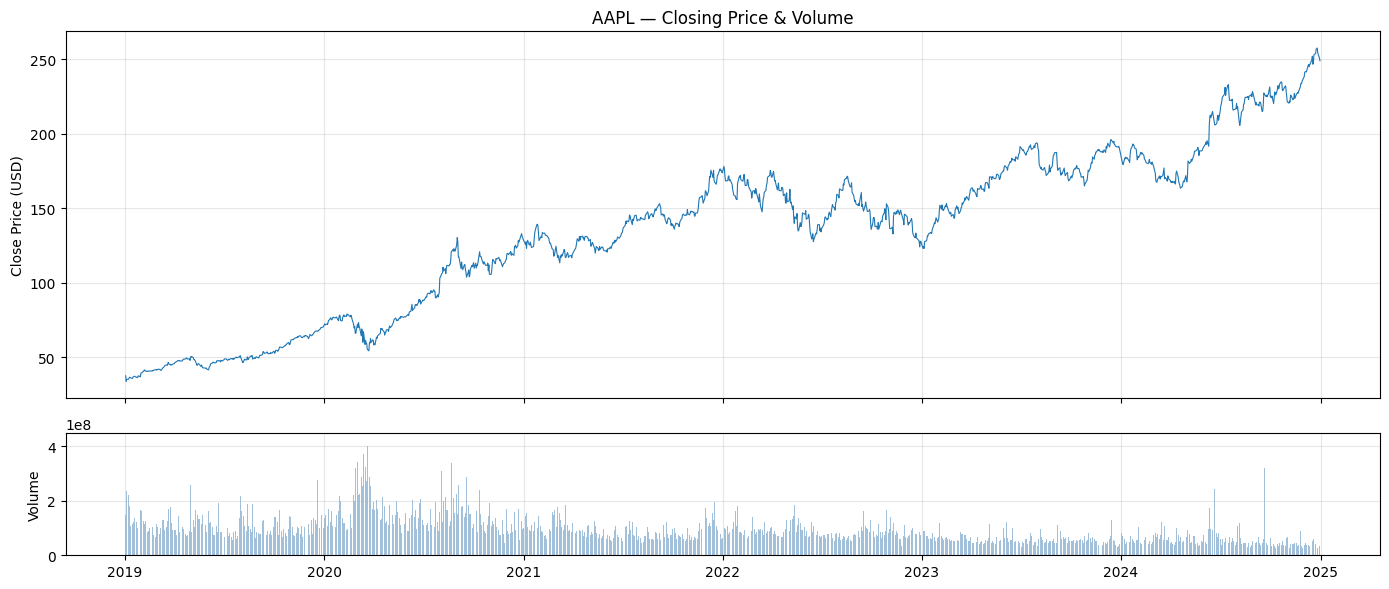

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1]})

axes[0].plot(df.index, df["Close"], linewidth=0.8)
axes[0].set_ylabel("Close Price (USD)")
axes[0].set_title(f"{TICKER} — Closing Price & Volume")
axes[0].grid(True, alpha=0.3)

axes[1].bar(df.index, df["Volume"], width=1, alpha=0.5, color="steelblue")
axes[1].set_ylabel("Volume")
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

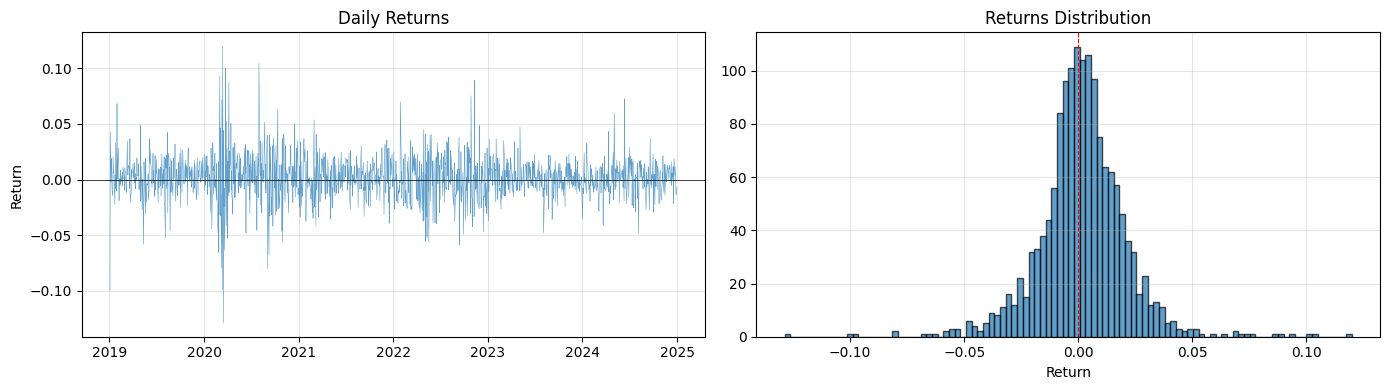

Mean daily return: 0.1444%
Std daily return:  1.9427%
Skewness:          -0.0096
Kurtosis:          5.5120


In [6]:
df["returns"] = df["Close"].pct_change()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(df.index, df["returns"], linewidth=0.4, alpha=0.7)
axes[0].set_title("Daily Returns")
axes[0].set_ylabel("Return")
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].grid(True, alpha=0.3)

axes[1].hist(df["returns"].dropna(), bins=100, edgecolor="black", alpha=0.7)
axes[1].set_title("Returns Distribution")
axes[1].set_xlabel("Return")
axes[1].axvline(0, color="red", linewidth=0.8, linestyle="--")
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

print(f"Mean daily return: {df['returns'].mean():.4%}")
print(f"Std daily return:  {df['returns'].std():.4%}")
print(f"Skewness:          {df['returns'].skew():.4f}")
print(f"Kurtosis:          {df['returns'].kurtosis():.4f}")

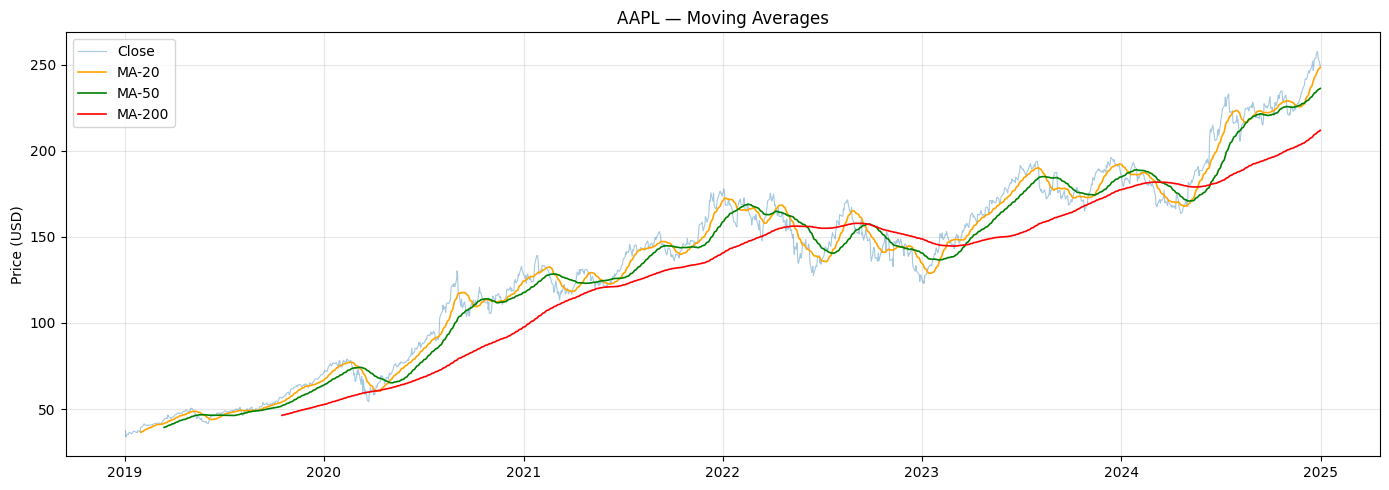

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df["Close"], alpha=0.4, linewidth=0.8, label="Close")
for window, color in [(20, "orange"), (50, "green"), (200, "red")]:
    ma = df["Close"].rolling(window).mean()
    ax.plot(df.index, ma, label=f"MA-{window}", color=color, linewidth=1.2)

ax.set_title(f"{TICKER} — Moving Averages")
ax.set_ylabel("Price (USD)")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

---
## 3. Feature Engineering & Model Training

We frame the problem as **supervised regression**: given features derived from past prices, predict the next day's closing price.

**Features** (all use shifted data to prevent look-ahead bias):
- **Lag features** — closing prices 1, 2, 3, 5, 10, 20 days ago
- **Rolling statistics** — moving average and standard deviation over 5 / 10 / 20 day windows
- **Calendar features** — day of week, month
- **Price-derived** — 1-day return, intraday range (High − Low) / Close

In [8]:
def create_features(df, target_col="Close"):
    """Build a feature matrix from an OHLCV DataFrame.

    All features are computed on shifted (past) data so
    they are available at prediction time without look-ahead.
    """
    feat = pd.DataFrame(index=df.index)

    # Lag features
    for lag in [1, 2, 3, 5, 10, 20]:
        feat[f"lag_{lag}"] = df[target_col].shift(lag)

    # Rolling statistics on shifted series
    shifted = df[target_col].shift(1)
    for w in [5, 10, 20]:
        feat[f"rolling_mean_{w}"] = shifted.rolling(w).mean()
        feat[f"rolling_std_{w}"] = shifted.rolling(w).std()

    # Calendar
    feat["day_of_week"] = df.index.dayofweek
    feat["month"] = df.index.month

    # Price-derived
    feat["return_1d"] = df[target_col].pct_change().shift(1)
    feat["range_pct"] = ((df["High"] - df["Low"]) / df[target_col]).shift(1)

    # Target
    feat["target"] = df[target_col]

    return feat.dropna()


features = create_features(df)
print(f"Feature matrix: {features.shape[0]} samples × {features.shape[1] - 1} features")
features.head()

Feature matrix: 1490 samples × 16 features


,lag_1,lag_2,lag_3,lag_5,lag_10,lag_20,rolling_mean_5,rolling_std_5,rolling_mean_10,rolling_std_10,rolling_mean_20,rolling_std_20,day_of_week,month,return_1d,range_pct,target
Date,,,,,,,,,,,,,,,,,
2019-01-31,39.244495,36.734272,37.119003,36.264053,36.796024,37.503731,37.365510,1.141607,37.084090,0.847366,36.466507,1.106463,3,1,0.068335,0.035824,39.527115
2019-02-01,39.527115,39.244495,36.734272,37.465725,37.014500,33.768078,38.018122,1.278953,37.357199,1.135379,36.567676,1.284477,4,2,0.007202,0.026676,39.546101
2019-02-04,39.546101,39.527115,39.244495,37.119003,37.242500,35.209614,38.434197,1.388062,37.610359,1.318025,36.856577,1.271380,0,2,0.000480,0.018316,40.669403
2019-02-05,40.669403,39.546101,39.527115,36.734272,36.406540,35.131245,39.144277,1.453634,37.953049,1.622165,37.129567,1.469809,1,2,0.028405,0.025577,41.365253
2019-02-06,41.365253,40.669403,39.546101,39.244495,36.553783,35.800957,40.070473,0.906589,38.448920,1.840149,37.441267,1.670976,2,2,0.017110,0.015673,41.379498


Training: 1192 samples  (2019-01-31 → 2023-10-24)
Testing:  298 samples  (2023-10-25 → 2024-12-31)


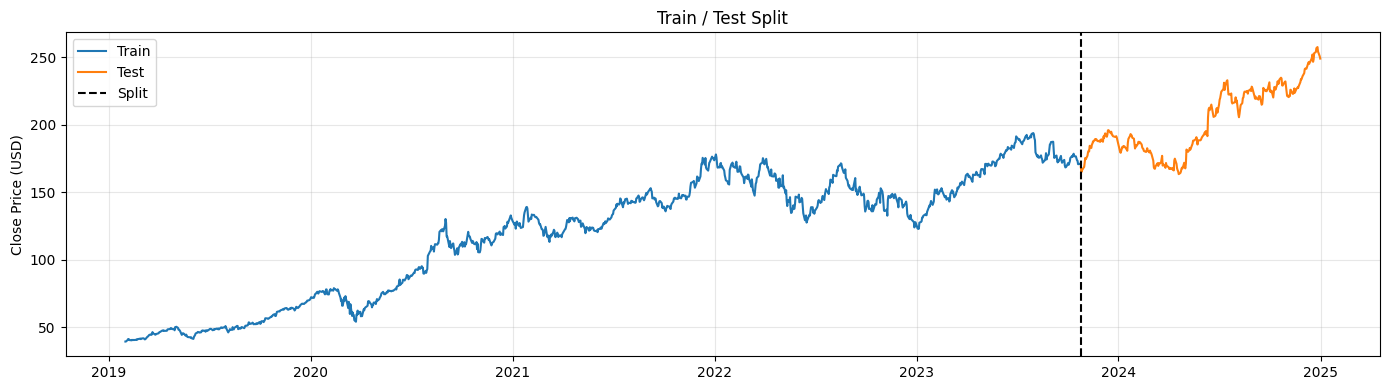

In [9]:
FEATURE_COLS = [c for c in features.columns if c != "target"]
TARGET_COL = "target"

# Time-based split — last 20 % for testing
split_idx = int(len(features) * 0.8)
split_date = features.index[split_idx]

X_train = features.iloc[:split_idx][FEATURE_COLS]
y_train = features.iloc[:split_idx][TARGET_COL]
X_test  = features.iloc[split_idx:][FEATURE_COLS]
y_test  = features.iloc[split_idx:][TARGET_COL]

print(f"Training: {len(X_train)} samples  ({X_train.index[0].date()} → {X_train.index[-1].date()})")
print(f"Testing:  {len(X_test)} samples  ({X_test.index[0].date()} → {X_test.index[-1].date()})")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_train.index, y_train, label="Train")
ax.plot(y_test.index, y_test, label="Test")
ax.axvline(split_date, color="black", linestyle="--", label="Split")
ax.set_title("Train / Test Split")
ax.set_ylabel("Close Price (USD)")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

In [10]:
# Naive baseline: "tomorrow's price = today's price" (persistence)
naive_preds = X_test["lag_1"]
naive_mae  = mean_absolute_error(y_test, naive_preds)
naive_rmse = np.sqrt(mean_squared_error(y_test, naive_preds))

print(f"Naive baseline (persistence)")
print(f"  MAE:  {naive_mae:.4f}")
print(f"  RMSE: {naive_rmse:.4f}")

Naive baseline (persistence)
  MAE:  2.0309
  RMSE: 2.7576


---
## 4. Experiment Tracking with MLflow

[MLflow](https://mlflow.org/) is an open-source platform for managing the ML lifecycle:

- **Tracking** — log parameters, metrics and artifacts for every experiment run
- **Models** — package models in a standard format, independent of the training library
- **Registry** — version and stage models (e.g. *staging → production*)

We will:
1. Train several models with different hyper-parameters
2. Log each run to MLflow
3. Compare runs and select the best model
4. Register it in the Model Registry for serving

In [11]:
EXPERIMENT_NAME = "stock_forecasting"

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"Tracking URI : {mlflow.get_tracking_uri()}")
print(f"Experiment   : {EXPERIMENT_NAME}")

Tracking URI : sqlite:///mlflow.db
Experiment   : stock_forecasting


In [12]:
model_configs = [
    {"name": "ridge_a1",    "model": Ridge(alpha=1.0)},
    {"name": "ridge_a10",   "model": Ridge(alpha=10.0)},
    {"name": "lasso_a1",    "model": Lasso(alpha=1.0)},
    {"name": "gbr_100_d3",  "model": GradientBoostingRegressor(
        n_estimators=100, max_depth=3, random_state=42)},
    {"name": "gbr_200_d5",  "model": GradientBoostingRegressor(
        n_estimators=200, max_depth=5, random_state=42)},
    {"name": "rf_100_d10",  "model": RandomForestRegressor(
        n_estimators=100, random_state=42)},
]

for cfg in model_configs:
    with mlflow.start_run(run_name=cfg["name"]) as run:
        m = cfg["model"]
        m.fit(X_train, y_train)
        preds = m.predict(X_test)

        mae  = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        r2   = r2_score(y_test, preds)

        mlflow.log_param("ticker", TICKER)
        mlflow.log_param("n_train", X_train.shape[0])
        mlflow.log_param("n_test", X_test.shape[0])
        mlflow.log_param("n_features", X_train.shape[1])
        mlflow.log_params({k: str(v) for k, v in m.get_params().items()})
        mlflow.log_metrics({"mae": mae, "rmse": rmse, "r2": r2})

        mlflow.sklearn.log_model(
            m, artifact_path="model",
            input_example=X_test.iloc[:1],
        )

        print(f"  {cfg['name']:15s} | MAE={mae:8.4f} | RMSE={rmse:8.4f} | R²={r2:.4f}")

print("\nAll runs logged to MLflow.")

2026/02/25 10:01:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/25 10:01:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/02/25 10:01:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/25 10:01:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

  ridge_a1        | MAE=  2.0421 | RMSE=  2.7704 | R²=0.9875


2026/02/25 10:01:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/25 10:01:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  ridge_a10       | MAE=  2.0442 | RMSE=  2.7722 | R²=0.9875
  lasso_a1        | MAE=  2.0630 | RMSE=  2.7759 | R²=0.9874


2026/02/25 10:01:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/25 10:01:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  gbr_100_d3      | MAE= 19.4534 | RMSE= 27.6681 | R²=-0.2476


2026/02/25 10:01:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/25 10:01:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  gbr_200_d5      | MAE= 20.3651 | RMSE= 28.7203 | R²=-0.3443


2026/02/25 10:02:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/25 10:02:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  rf_100_d10      | MAE= 18.9767 | RMSE= 26.8329 | R²=-0.1734

All runs logged to MLflow.


In [13]:
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
runs_df = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["metrics.rmse ASC"],
)

cols = ["tags.mlflow.runName", "metrics.mae", "metrics.rmse", "metrics.r2"]
runs_df[cols].head(10)

,tags.mlflow.runName,metrics.mae,metrics.rmse,metrics.r2
0,ridge_a1,2.042094,2.770386,0.987492
1,ridge_a1,2.042094,2.770386,0.987492
2,ridge_a1,2.042094,2.770386,0.987492
3,ridge_a1,2.042094,2.770386,0.987492
4,ridge_a10,2.044245,2.772230,0.987475
5,ridge_a10,2.044246,2.772230,0.987475
6,ridge_a10,2.044246,2.772230,0.987475
7,ridge_a10,2.044246,2.772230,0.987475
8,lasso_a1,2.063039,2.775932,0.987442
9,lasso_a1,2.063040,2.775932,0.987442


In [14]:
best_run = runs_df.iloc[0]
best_run_id   = best_run.run_id
best_run_name = best_run["tags.mlflow.runName"]

print(f"Best model: {best_run_name}")
print(f"  run_id : {best_run_id}")
print(f"  MAE    : {best_run['metrics.mae']:.4f}")
print(f"  RMSE   : {best_run['metrics.rmse']:.4f}")
print(f"  R²     : {best_run['metrics.r2']:.4f}")

# Register in the MLflow Model Registry
MODEL_NAME = "stock_forecasting_model"
reg = mlflow.register_model(f"runs:/{best_run_id}/model", MODEL_NAME)
print(f"\nRegistered as '{MODEL_NAME}' version {reg.version}")

Registered model 'stock_forecasting_model' already exists. Creating a new version of this model...
2026/02/25 10:02:01 WARNING mlflow.tracking._model_registry.fluent: Run with id 6405672791f64d76900d29a24b9c9546 has no artifacts at artifact path 'model', registering model based on models:/m-756253b454ff40af9aa5531e657fa7e7 instead


Best model: ridge_a1
  run_id : 6405672791f64d76900d29a24b9c9546
  MAE    : 2.0421
  RMSE   : 2.7704
  R²     : 0.9875

Registered as 'stock_forecasting_model' version 2


Created version '2' of model 'stock_forecasting_model'.


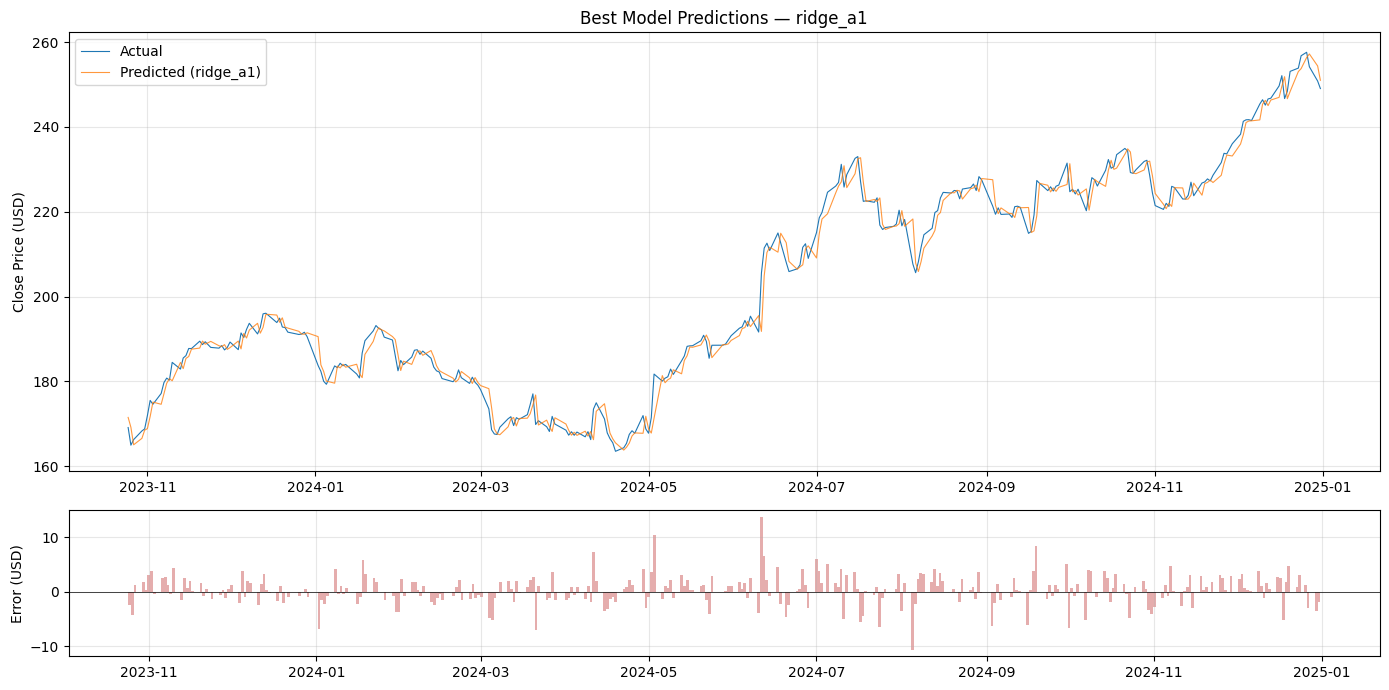

In [15]:
best_model = mlflow.sklearn.load_model(f"runs:/{best_run_id}/model")
best_preds = best_model.predict(X_test)

fig, axes = plt.subplots(2, 1, figsize=(14, 7),
                         gridspec_kw={"height_ratios": [3, 1]})

axes[0].plot(y_test.index, y_test.values, label="Actual", linewidth=0.8)
axes[0].plot(y_test.index, best_preds, label=f"Predicted ({best_run_name})",
             linewidth=0.8, alpha=0.8)
axes[0].set_title(f"Best Model Predictions — {best_run_name}")
axes[0].set_ylabel("Close Price (USD)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

errors = y_test.values - best_preds
axes[1].bar(y_test.index, errors, width=1, alpha=0.5, color="indianred")
axes[1].set_ylabel("Error (USD)")
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

> **Tip — MLflow UI**: You can explore all experiments interactively by running in a terminal:
> ```bash
> mlflow ui --backend-store-uri sqlite:///mlflow.db
> ```
> then opening http://localhost:5000 in your browser.

---
## 5. Model Serving with FastAPI

[FastAPI](https://fastapi.tiangolo.com/) is a modern Python web framework for building APIs. Key advantages:

- Automatic **request validation** via Pydantic models
- Auto-generated **interactive docs** (Swagger UI at `/docs`)
- **Async** support and high performance

Our API will:
1. Load the best model from the MLflow Registry on startup
2. Expose a `/predict` endpoint accepting pre-computed features
3. Expose a `/forecast` endpoint that fetches live data for a ticker and returns the prediction

In [16]:
# Save model configuration so the serving script can find the model
serve_config = {
    "model_name": MODEL_NAME,
    "model_version": str(reg.version),
    "feature_columns": FEATURE_COLS,
    "ticker": TICKER,
    "tracking_uri": mlflow.get_tracking_uri(),
}

with open("serve_config.json", "w") as f:
    json.dump(serve_config, f, indent=2)

print("serve_config.json:")
print(json.dumps(serve_config, indent=2))

serve_config.json:
{
  "model_name": "stock_forecasting_model",
  "model_version": "2",
  "feature_columns": [
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_5",
    "lag_10",
    "lag_20",
    "rolling_mean_5",
    "rolling_std_5",
    "rolling_mean_10",
    "rolling_std_10",
    "rolling_mean_20",
    "rolling_std_20",
    "day_of_week",
    "month",
    "return_1d",
    "range_pct"
  ],
  "ticker": "AAPL",
  "tracking_uri": "sqlite:///mlflow.db"
}


In [17]:
%%writefile serve.py
"""FastAPI server for stock-price forecasting."""

import json
import mlflow
import yfinance as yf
import pandas as pd
import numpy as np
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel

# ── Configuration & model loading ─────────────────────────────────────────

with open("serve_config.json") as f:
    CONFIG = json.load(f)

mlflow.set_tracking_uri(CONFIG["tracking_uri"])
MODEL = mlflow.sklearn.load_model(
    f"models:/{CONFIG['model_name']}/{CONFIG['model_version']}"
)
FEATURE_COLS = CONFIG["feature_columns"]

app = FastAPI(
    title="Stock Forecasting API",
    description="Next-day stock-price predictions backed by an MLflow-tracked model.",
)


# ── Schemas ───────────────────────────────────────────────────────────────

class PredictRequest(BaseModel):
    """Pre-computed feature values for a single prediction."""
    features: dict


class ForecastRequest(BaseModel):
    """Ticker-based request — the server fetches data and computes features."""
    ticker: str = "AAPL"


class ForecastResponse(BaseModel):
    ticker: str
    last_close: float
    predicted_close: float
    predicted_change_pct: float


# ── Feature engineering (mirrors training code) ────────────────────────────

def create_features(df, target_col="Close"):
    feat = pd.DataFrame(index=df.index)
    for lag in [1, 2, 3, 5, 10, 20]:
        feat[f"lag_{lag}"] = df[target_col].shift(lag)
    shifted = df[target_col].shift(1)
    for w in [5, 10, 20]:
        feat[f"rolling_mean_{w}"] = shifted.rolling(w).mean()
        feat[f"rolling_std_{w}"] = shifted.rolling(w).std()
    feat["day_of_week"] = df.index.dayofweek
    feat["month"] = df.index.month
    feat["return_1d"] = df[target_col].pct_change().shift(1)
    feat["range_pct"] = ((df["High"] - df["Low"]) / df[target_col]).shift(1)
    return feat.dropna()


# ── Endpoints ─────────────────────────────────────────────────────────────

@app.get("/health")
def health():
    return {
        "status": "healthy",
        "model": CONFIG["model_name"],
        "version": CONFIG["model_version"],
    }


@app.post("/predict")
def predict(request: PredictRequest):
    """Return a prediction from pre-computed features."""
    try:
        X = pd.DataFrame([request.features])[FEATURE_COLS]
        prediction = float(MODEL.predict(X)[0])
        return {"predicted_close": round(prediction, 2)}
    except Exception as e:
        raise HTTPException(status_code=400, detail=str(e))


@app.post("/forecast", response_model=ForecastResponse)
def forecast(request: ForecastRequest):
    """Fetch recent market data for *ticker* and predict next-day close."""
    try:
        tk = yf.Ticker(request.ticker)
        df = tk.history(period="6mo")
        if df.empty:
            raise HTTPException(status_code=404,
                                detail=f"No data found for {request.ticker}")
        df.index = df.index.tz_localize(None)
        df = df[["Open", "High", "Low", "Close", "Volume"]]

        feats = create_features(df)
        X = feats[FEATURE_COLS].iloc[[-1]]
        prediction = float(MODEL.predict(X)[0])
        last_close = float(df["Close"].iloc[-1])

        return ForecastResponse(
            ticker=request.ticker,
            last_close=round(last_close, 2),
            predicted_close=round(prediction, 2),
            predicted_change_pct=round(
                (prediction - last_close) / last_close * 100, 2
            ),
        )
    except HTTPException:
        raise
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))

Overwriting serve.py


In [18]:
import subprocess, sys, time

server = subprocess.Popen(
    [sys.executable, "-m", "uvicorn", "serve:app",
     "--host", "127.0.0.1", "--port", "8000"],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
)
time.sleep(5)  # give the server a moment to start
print(f"Server started  (PID {server.pid})")

Server started  (PID 58995)


In [19]:
import httpx

BASE = "http://127.0.0.1:8000"

# 1 — Health check
print("── Health Check ──")
r = httpx.get(f"{BASE}/health")
print(f"  {r.status_code}  {r.json()}")

# 2 — Predict with raw features (use last test sample)
print("\n── /predict  (pre-computed features) ──")
sample = X_test.iloc[-1].to_dict()
r = httpx.post(f"{BASE}/predict", json={"features": sample})
print(f"  {r.status_code}  {r.json()}")
print(f"  Actual close: {y_test.iloc[-1]:.2f}")

# 3 — Forecast by ticker (fetches live data)
print("\n── /forecast  (live data) ──")
r = httpx.post(f"{BASE}/forecast", json={"ticker": "AAPL"})
print(f"  {r.status_code}  {r.json()}")

── Health Check ──
  200  {'status': 'healthy', 'model': 'stock_forecasting_model', 'version': '2'}

── /predict  (pre-computed features) ──
  200  {'predicted_close': 251.01}
  Actual close: 249.06

── /forecast  (live data) ──
  200  {'ticker': 'AAPL', 'last_close': 272.14, 'predicted_close': 266.0, 'predicted_change_pct': -2.25}


> **Interactive docs**: While the server is running, open http://localhost:8000/docs to explore the auto-generated Swagger UI and test the endpoints from your browser.

In [20]:
server.terminate()
server.wait()
print("Server stopped.")

Server stopped.


---
## Summary & Next Steps

We built a **complete (simplified) forecasting pipeline**:

| Step | What we did | Production upgrade |
|:-----|:------------|:-------------------|
| Data Retrieval | `yfinance` | Scheduled data pipeline (Airflow / Prefect) |
| EDA | Manual analysis in notebook | Automated data-quality checks (Great Expectations) |
| Feature Engineering | Lag / rolling features | Feature store (Feast, Tecton) |
| Model Training | scikit-learn | AutoML, hyper-parameter search (Optuna) |
| Experiment Tracking | MLflow (local SQLite) | MLflow Tracking Server with remote storage |
| Serving | FastAPI (local) | Containerised deployment (Docker + Kubernetes) |

### Exercises

1. **Different tickers** — Change `TICKER` and re-run. How does performance change?
2. **More features** — Add technical indicators (RSI, MACD, Bollinger Bands) and see if metrics improve.
3. **Hyper-parameter search** — Combine MLflow with [Optuna](https://optuna.org/) or `GridSearchCV` and log every trial.
4. **Model monitoring** — Add a `/metrics` endpoint that compares recent predictions vs. actuals to detect drift.
5. **Dockerise** — Write a `Dockerfile` for `serve.py` so the API can run anywhere.